# OLCI L3 water-band smoke test

One day of **real Sentinel-3 OLCI** Level-3 mapped Rrs, sampled at the existing CHLA-Z parquet `lat` / `lon` / `time`.

NASA delayed-mode `OLCIS3A_L3m_ERR_RRS` and `OLCIS3B_L3m_ERR_RRS`, daily 4 km, **all 11 water bands**:
400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709 nm.

Each band is a separate granule (`*.DAY.*.Rrs_<nm>.4km.nc`). S3A is used when the pixel is finite, otherwise S3B. Compare each `olci_Rrs_*` to the nearest PACE column.

Default day: **2024-07-08**. Kernel: `gobgc`. Needs `~/.netrc` Earthdata login.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import earthaccess

DAY = "2024-07-08"
OLCI_BANDS = [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]
GRANULE = "*.DAY.*.Rrs_*.4km.nc"
SHORT_S3A = "OLCIS3A_L3m_ERR_RRS"
SHORT_S3B = "OLCIS3B_L3m_ERR_RRS"

DATA = Path("/Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data")
if not (DATA / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        cand = p.parent / "chla-z" / "brt_training_data"
        if (cand / "CHLA_argo_profiles_plus_PACE.parquet").is_file():
            DATA = cand
            break
print("DATA:", DATA)
print("DAY:", DAY)
print("OLCI bands:", OLCI_BANDS)

DATA: /Users/nmamnun/GO-BGC-Workshop/chla-z/brt_training_data
DAY: 2024-07-08
OLCI bands: [400, 412, 443, 490, 510, 560, 620, 665, 674, 681, 709]


/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Profiles on this day

Keep rows that already have PACE Rrs so the scatter is OLCI vs PACE on the same `profile_id`. Map each OLCI band to the nearest `pace_Rrs_*` column.

In [2]:
def nearest_pace_col(olci_nm, pace_cols):
    waves = np.array([int(c.split("_")[-1]) for c in pace_cols])
    return pace_cols[int(np.argmin(np.abs(waves - olci_nm)))]


def load_pace_matched(data_dir: Path) -> pd.DataFrame:
    argo = pd.read_parquet(data_dir / "CHLA_argo_profiles_plus_PACE.parquet")
    argo = argo.rename(columns={"LATITUDE": "lat", "LONGITUDE": "lon", "TIME": "time"})
    argo["source"] = "argo"
    ooi = pd.read_parquet(data_dir / "CHLA_ooi_profiles_plus_PACE.parquet")
    ooi["source"] = "ooi"
    rrs_cols = [c for c in argo.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
    keep = ["profile_id", "time", "lat", "lon", "source"] + rrs_cols
    frames = []
    for df in (argo, ooi):
        sub = df[keep].dropna(subset=rrs_cols, how="all").copy()
        frames.append(sub)
    out = pd.concat(frames, ignore_index=True)
    out["time"] = pd.to_datetime(out["time"], utc=True)
    return out, rrs_cols

all_pts, pace_rrs_cols = load_pace_matched(DATA)
PACE_FOR_OLCI = {nm: nearest_pace_col(nm, pace_rrs_cols) for nm in OLCI_BANDS}
print("OLCI -> nearest PACE")
for nm, col in PACE_FOR_OLCI.items():
    print(f"  {nm:3d} -> {col}")

d0 = pd.Timestamp(DAY, tz="UTC").normalize()
pts = all_pts[(all_pts["time"] >= d0) & (all_pts["time"] < d0 + pd.Timedelta(1, unit="D"))].copy()
pts = pts.reset_index(drop=True)
print(f"\nPACE-matched profiles on {DAY}: {len(pts)} "
      f"(argo {(pts.source=='argo').sum()}, ooi {(pts.source=='ooi').sum()})")
pts[["profile_id", "source", "time", "lat", "lon"] + list(PACE_FOR_OLCI.values())]

OLCI -> nearest PACE
  400 -> pace_Rrs_400
  412 -> pace_Rrs_413
  443 -> pace_Rrs_442
  490 -> pace_Rrs_490
  510 -> pace_Rrs_510
  560 -> pace_Rrs_560
  620 -> pace_Rrs_620
  665 -> pace_Rrs_665
  674 -> pace_Rrs_673
  681 -> pace_Rrs_681
  709 -> pace_Rrs_709

PACE-matched profiles on 2024-07-08: 9 (argo 4, ooi 5)


,profile_id,source,time,lat,lon,pace_Rrs_400,pace_Rrs_413,pace_Rrs_442,pace_Rrs_490,pace_Rrs_510,pace_Rrs_560,pace_Rrs_620,pace_Rrs_665,pace_Rrs_673,pace_Rrs_681,pace_Rrs_709
0,7901007_0246,argo,2024-07-08 10:32:00+00:00,74.555958,33.638365,0.008378,0.006972,0.005518,0.004318,0.003848,0.003130,0.001236,0.000762,0.000910,0.000966,0.000318
1,4903026_0336,argo,2024-07-08 13:25:11.424000+00:00,37.169120,-125.163060,0.005538,0.004986,0.004418,0.004090,0.002992,0.001462,0.000206,0.000186,0.000208,0.000214,0.000162
2,7902111_0001,argo,2024-07-08 16:46:47.002000128+00:00,40.043200,-139.964100,0.011552,0.011030,0.009584,0.006864,0.004080,0.001782,0.000414,0.000250,0.000230,0.000226,0.000184
3,5906293_0154,argo,2024-07-08 20:15:50.002000128+00:00,51.542000,-129.525000,0.003606,0.003334,0.003356,0.003694,0.003296,0.002244,0.000478,0.000306,0.000334,0.000344,0.000176
4,ooi-ce07shsp-sp001-07-flortj000_20240708,ooi,2024-07-08 00:00:00+00:00,46.988050,-124.566330,0.002406,0.001982,0.001916,0.002344,0.002360,0.003146,0.000796,0.000444,0.000532,0.000644,0.000358
5,ooi-ce04ossm-rid27-02-flortd000_20240708,ooi,2024-07-08 00:00:00+00:00,44.365280,-124.939470,0.002800,0.002492,0.002618,0.003330,0.003500,0.003294,0.000724,0.000520,0.000572,0.000606,0.000358
6,ooi-ce09ospm-wfp01-04-flortk000_20240708,ooi,2024-07-08 00:00:00+00:00,46.852180,-124.974610,0.004954,0.005004,0.005820,0.006628,0.005584,0.003568,0.000664,0.000426,0.000430,0.000416,0.000226
7,ooi-ce04osps-sf01b-3a-flortd104_20240708,ooi,2024-07-08 00:00:00+00:00,44.369353,-124.954108,0.002800,0.002492,0.002618,0.003330,0.003500,0.003294,0.000724,0.000520,0.000572,0.000606,0.000358
8,ooi-rs01sbps-sf01a-3a-flortd101_20240708,ooi,2024-07-08 00:00:00+00:00,44.528951,-125.389669,0.002790,0.002670,0.003222,0.003852,0.003098,0.001796,0.000320,0.000224,0.000216,0.000212,0.000164


## 2. Earthdata login and OLCI granules

One search per satellite, then keep only the 11 daily 4 km water-band files. A bare temporal search also returns mission-climatology (`L3m.MC`) files.

In [3]:
auth = earthaccess.login()
if not auth.authenticated:
    auth = earthaccess.login(strategy="interactive", persist=True)
print("authenticated:", auth.authenticated)


def band_from_link(link: str):
    for nm in OLCI_BANDS:
        if f"Rrs_{nm}.4km" in link:
            return nm
    return None


def search_day_bands(short_name: str):
    results = earthaccess.search_data(
        short_name=short_name,
        temporal=(DAY, DAY),
        granule_name=GRANULE,
    )
    ymd = pd.Timestamp(DAY).strftime("%Y%m%d")
    by_band = {}
    for g in results:
        link = g.data_links()[0] if g.data_links() else ""
        if ymd not in link or ".DAY." not in link:
            continue
        nm = band_from_link(link)
        if nm is None:
            continue
        by_band[nm] = g
    missing = [nm for nm in OLCI_BANDS if nm not in by_band]
    print(f"{short_name}: {len(results)} search hits, {len(by_band)}/{len(OLCI_BANDS)} water bands")
    for nm in OLCI_BANDS:
        if nm in by_band:
            print(" ", by_band[nm].data_links()[0].rsplit("/", 1)[-1])
    if missing:
        print("  missing:", missing)
    return by_band

s3a_hits = search_day_bands(SHORT_S3A)
s3b_hits = search_day_bands(SHORT_S3B)

authenticated: True


/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


OLCIS3A_L3m_ERR_RRS: 11 search hits, 11/11 water bands
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_400.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_412.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_443.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_490.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_510.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_560.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_620.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_665.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_674.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_681.4km.nc
  S3A_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_709.4km.nc
OLCIS3B_L3m_ERR_RRS: 11 search hits, 11/11 water bands
  S3B_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_400.4km.nc
  S3B_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_412.4km.nc
  S3B_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_443.4km.nc
  S3B_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_490.4km.nc
  S3B_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_510.4km.nc
  S3B_OLCI_ERRNT.20240708.L3m.DAY.RRS.Rrs_

## 3. Nearest-neighbor sample (all 11 bands)

Same lat/lon indexer as the `Rrs_443` test. Per band: S3A if finite, else S3B.

In [4]:
def sample_rrs(ds, lats, lons, var):
    if var not in ds.data_vars and "Rrs" in ds.data_vars:
        var = "Rrs"
    lat_idx = ds.get_index("lat")
    lon_idx = ds.get_index("lon")
    i = lat_idx.get_indexer(np.asarray(lats, dtype=float), method="nearest")
    j = lon_idx.get_indexer(np.asarray(lons, dtype=float), method="nearest")
    vals = np.asarray(ds[var].values, dtype=float)[i, j]
    return vals


def sample_sensor(hits, prefix):
    for nm in OLCI_BANDS:
        col = f"{prefix}_Rrs_{nm}"
        pts[col] = np.nan
        g = hits.get(nm)
        if g is None:
            print(f"  {prefix} Rrs_{nm}: no granule")
            continue
        files = earthaccess.open([g], pqdm_kwargs={"disable": True})
        ds = xr.open_dataset(files[0])
        var = f"Rrs_{nm}"
        vals = sample_rrs(ds, pts["lat"], pts["lon"], var)
        pts[col] = vals
        n_ok = int(np.isfinite(vals).sum())
        print(f"  {prefix} {var}: {n_ok}/{len(vals)} finite")
        ds.close()

print("S3A")
sample_sensor(s3a_hits, "s3a")
print("S3B")
sample_sensor(s3b_hits, "s3b")

olci_cols = []
for nm in OLCI_BANDS:
    a = pts[f"s3a_Rrs_{nm}"]
    b = pts[f"s3b_Rrs_{nm}"]
    col = f"olci_Rrs_{nm}"
    pts[col] = np.where(np.isfinite(a), a, b)
    olci_cols.append(col)

n_any = int(pts[olci_cols].notna().any(axis=1).sum())
n_all = int(pts[olci_cols].notna().all(axis=1).sum())
print(f"\nS3A else S3B: any band finite {n_any}/{len(pts)}, all 11 finite {n_all}/{len(pts)}")
pts[["profile_id", "source"] + olci_cols]

S3A


/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


  s3a Rrs_400: 2/9 finite


/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


  s3a Rrs_412: 2/9 finite


...

/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


  s3b Rrs_681: 6/9 finite


/opt/homebrew/Caskroom/miniforge/base/envs/gobgc/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


  s3b Rrs_709: 6/9 finite

S3A else S3B: any band finite 7/9, all 11 finite 7/9


,profile_id,source,olci_Rrs_400,olci_Rrs_412,olci_Rrs_443,olci_Rrs_490,olci_Rrs_510,olci_Rrs_560,olci_Rrs_620,olci_Rrs_665,olci_Rrs_674,olci_Rrs_681,olci_Rrs_709
0,7901007_0246,argo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4903026_0336,argo,0.004994,0.005034,0.004888,0.004348,0.003066,0.001602,0.000224,0.000140,0.000174,0.000194,-0.000114
2,7902111_0001,argo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5906293_0154,argo,0.003504,0.003816,0.003930,0.003854,0.003306,0.002360,0.000594,0.000354,0.000376,0.000384,0.000010
4,ooi-ce07shsp-sp001-07-flortj000_20240708,ooi,0.002296,0.002456,0.002400,0.002478,0.002416,0.003522,0.001170,0.000726,0.000866,0.001008,0.000168
5,ooi-ce04ossm-rid27-02-flortd000_20240708,ooi,0.002340,0.002620,0.003280,0.003750,0.003394,0.002672,0.000580,0.000366,0.000386,0.000384,0.000020
6,ooi-ce09ospm-wfp01-04-flortk000_20240708,ooi,0.002816,0.003170,0.004148,0.004586,0.003832,0.002636,0.000518,0.000302,0.000300,0.000300,0.000022
7,ooi-ce04osps-sf01b-3a-flortd104_20240708,ooi,0.002340,0.002620,0.003280,0.003750,0.003394,0.002672,0.000580,0.000366,0.000386,0.000384,0.000020
8,ooi-rs01sbps-sf01a-3a-flortd101_20240708,ooi,0.001970,0.002238,0.003072,0.003226,0.002476,0.001530,0.000316,0.000178,0.000182,0.000172,-0.000064


## 4. OLCI vs nearest PACE band

 olci_nm     pace_col  n     corr
     400 pace_Rrs_400  7 0.821627
     412 pace_Rrs_413  7 0.759724
     443 pace_Rrs_442  7 0.779007
     490 pace_Rrs_490  7 0.782741
     510 pace_Rrs_510  7 0.810521
     560 pace_Rrs_560  7 0.814395
     620 pace_Rrs_620  7 0.778958
     665 pace_Rrs_665  7 0.596902
     674 pace_Rrs_673  7 0.630475
     681 pace_Rrs_681  7 0.702035
     709 pace_Rrs_709  7 0.714770


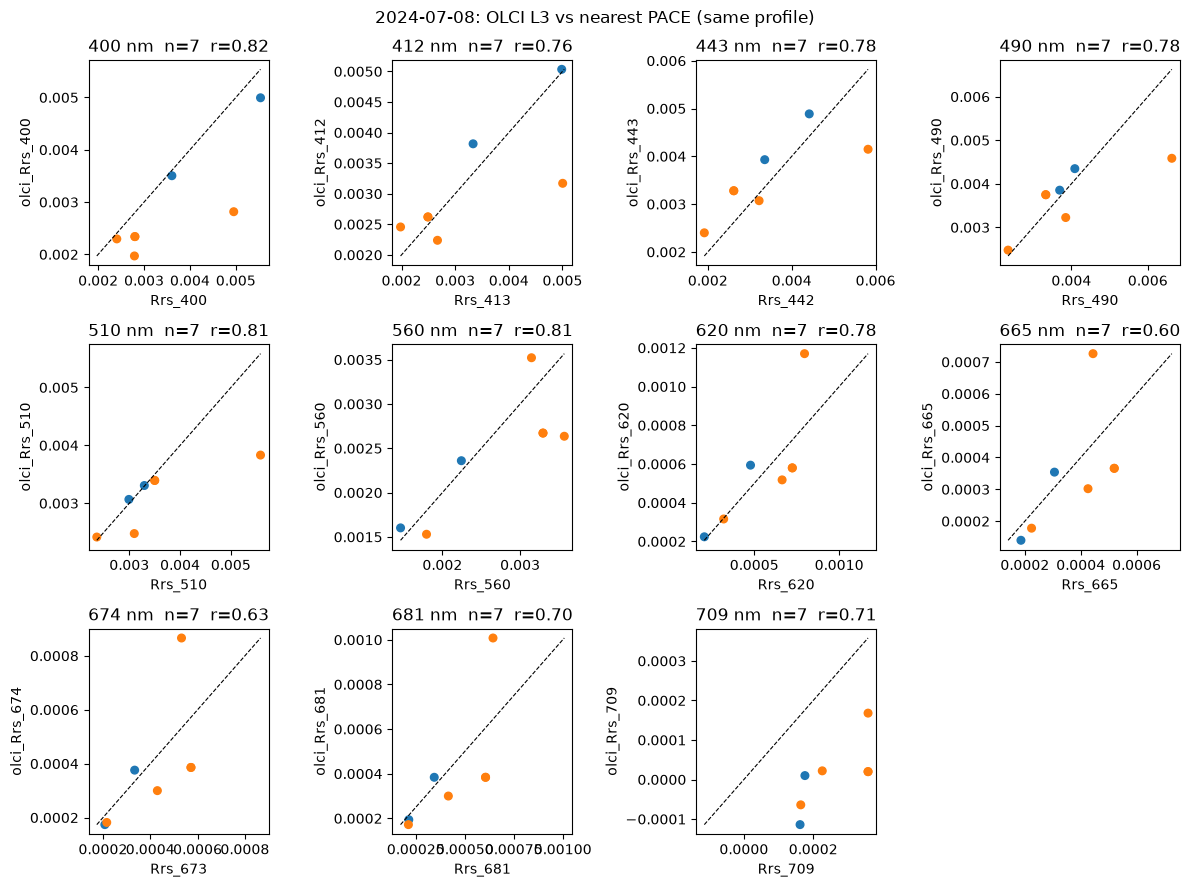

In [5]:
rows = []
for nm in OLCI_BANDS:
    ocol = f"olci_Rrs_{nm}"
    pcol = PACE_FOR_OLCI[nm]
    both = pts[np.isfinite(pts[ocol]) & np.isfinite(pts[pcol])]
    r = np.corrcoef(both[ocol], both[pcol])[0, 1] if len(both) >= 2 else np.nan
    rows.append({"olci_nm": nm, "pace_col": pcol, "n": len(both), "corr": r})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()
for i, nm in enumerate(OLCI_BANDS):
    ax = axes[i]
    ocol = f"olci_Rrs_{nm}"
    pcol = PACE_FOR_OLCI[nm]
    both = pts[np.isfinite(pts[ocol]) & np.isfinite(pts[pcol])]
    if len(both):
        ax.scatter(
            both[pcol], both[ocol],
            c=both["source"].map({"argo": "C0", "ooi": "C1"}),
            s=30,
        )
        lo = min(both[pcol].min(), both[ocol].min())
        hi = max(both[pcol].max(), both[ocol].max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    r = summary.loc[summary.olci_nm == nm, "corr"].iloc[0]
    n = int(summary.loc[summary.olci_nm == nm, "n"].iloc[0])
    ax.set_title(f"{nm} nm  n={n}  r={r:.2f}" if np.isfinite(r) else f"{nm} nm  n={n}")
    ax.set_xlabel(pcol.replace("pace_", ""))
    ax.set_ylabel(f"olci_Rrs_{nm}")
axes[-1].axis("off")
fig.suptitle(f"{DAY}: OLCI L3 vs nearest PACE (same profile)")
fig.tight_layout()